In [2]:
import matplotlib.pyplot as plt

def plot_meter_with_anomalies(df_features, title="Water meter with anomalies"):
    """
    df_features: output from engineer_features_and_train_negbin
                 must contain columns 'timestamp_utc', 'Diff', 'is_anomaly'
    """
    df_plot = df_features.sort_values("timestamp_utc")

    plt.figure(figsize=(14, 5))

    # All points
    plt.plot(
        df_plot["timestamp_utc"],
        df_plot["Diff"],
        label="Diff",
        color="blue",
        linewidth=1
    )

    # Anomalies
    anomalies = df_plot[df_plot["is_anomaly"]]
    plt.scatter(
        anomalies["timestamp_utc"],
        anomalies["Diff"],
        color="red",
        label="Anomalies",
        zorder=3
    )

    plt.xlabel("Time")
    plt.ylabel("Diff (water consumption increment)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example after training:
# model, df_with_anomalies = engineer_features_and_train_negbin(df_meter)
# plot_meter_with_anomalies(df_with_anomalies, title="Meter 1234 - Diff with anomalies")


In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

def engineer_features_and_train_iforest(df, contamination=0.01, random_state=42):
    """
    Engineer Fourier harmonic features and train Isolation Forest.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Must have columns 'timestamp_utc' and 'Diff'
    contamination : float
        Expected proportion of outliers (default 0.01 = 1%)
    random_state : int
        Random seed for reproducibility
        
    Returns:
    --------
    model : IsolationForest
        Trained model
    df_features : pandas.DataFrame
        DataFrame with engineered features and anomaly scores
    """
    
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Ensure timestamp is datetime
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])

    df.dropna(inplace=True)
    
    # Convert timestamp to seconds since epoch (for periodic calculations)
    df['timestamp_seconds'] = df['timestamp_utc'].astype(np.int64) / 1e9
    
    # Daily period: 86400 seconds (24 hours)
    daily_period = 86400
    df['sin_daily'] = np.sin(2 * np.pi * df['timestamp_seconds'] / daily_period)
    df['cos_daily'] = np.cos(2 * np.pi * df['timestamp_seconds'] / daily_period)
    
    # Weekly period: 604800 seconds (7 days)
    weekly_period = 604800
    df['sin_weekly'] = np.sin(2 * np.pi * df['timestamp_seconds'] / weekly_period)
    df['cos_weekly'] = np.cos(2 * np.pi * df['timestamp_seconds'] / weekly_period)
    
    # Prepare feature matrix
    feature_columns = ['Diff', 'sin_daily', 'cos_daily', 'sin_weekly', 'cos_weekly']
    X = df[feature_columns].values
    
    # Handle potential NaN values in Diff
    if np.isnan(X).any():
        print(f"Warning: Found {np.isnan(X).sum()} NaN values. Filling with 0.")
        X = np.nan_to_num(X, nan=0.0)
    
    # Train Isolation Forest
    model = IsolationForest(
        contamination=contamination,
        random_state=random_state,
        n_estimators=100
    )
    
    # Fit and predict
    df['anomaly_label'] = model.fit_predict(X)  # -1 for anomalies, 1 for normal
    df['anomaly_score'] = model.score_samples(X)  # Lower score = more anomalous
    
    # Create output dataframe with relevant columns
    df_features = df[['timestamp_utc', 'Diff', 'sin_daily', 'cos_daily', 
                       'sin_weekly', 'cos_weekly', 'anomaly_label', 'anomaly_score']]
    
    # Add binary anomaly flag (True/False for easier filtering)
    df_features['is_anomaly'] = df_features['anomaly_label'] == -1
    
    # Summary statistics
    n_anomalies = (df_features['is_anomaly']).sum()
    print(f"\n=== Isolation Forest Training Complete ===")
    print(f"Total samples: {len(df_features)}")
    print(f"Detected anomalies: {n_anomalies} ({100*n_anomalies/len(df_features):.2f}%)")
    print(f"Contamination parameter: {contamination}")
    
    return model, df_features


# Example usage:
#df = pd.DataFrame({
#    'timestamp_utc': pd.date_range('2024-01-01', periods=1000, freq='30min'),
#    'Diff': np.random.randn(1000) * 10 + 50
#})
#
#model, df_with_anomalies = engineer_features_and_train_iforest(df, contamination=0.05)
#
## Get anomalies
#anomalies = df_with_anomalies[df_with_anomalies['is_anomaly']]
#print(anomalies)


In [4]:
df = pd.read_csv('../data_w_diff_001/121771.csv')
model, df_with_anomalies_001 = engineer_features_and_train_iforest(df, contamination=0.01)


=== Isolation Forest Training Complete ===
Total samples: 42578
Detected anomalies: 426 (1.00%)
Contamination parameter: 0.01


C:\Users\Ondřej Černý\AppData\Local\Temp\ipykernel_15428\481756850.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['is_anomaly'] = df_features['anomaly_label'] == -1


In [5]:
model, df_with_anomalies_auto = engineer_features_and_train_iforest(df, contamination='auto')


=== Isolation Forest Training Complete ===
Total samples: 42578
Detected anomalies: 41638 (97.79%)
Contamination parameter: auto


C:\Users\Ondřej Černý\AppData\Local\Temp\ipykernel_15428\481756850.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['is_anomaly'] = df_features['anomaly_label'] == -1


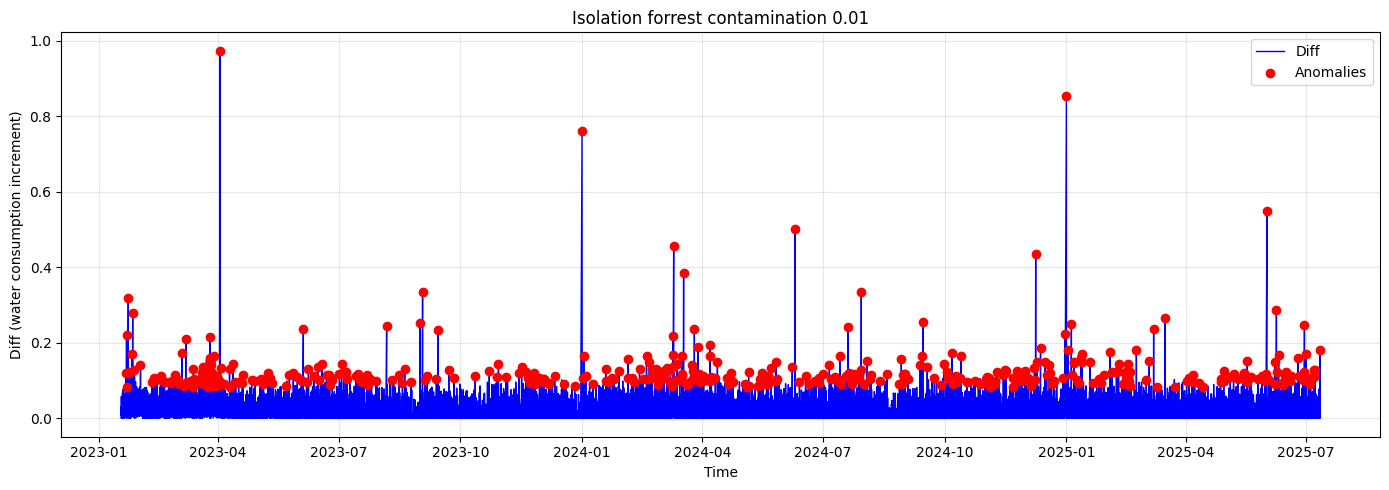

In [6]:
plot_meter_with_anomalies(df_with_anomalies_001, title="Isolation forrest contamination 0.01")

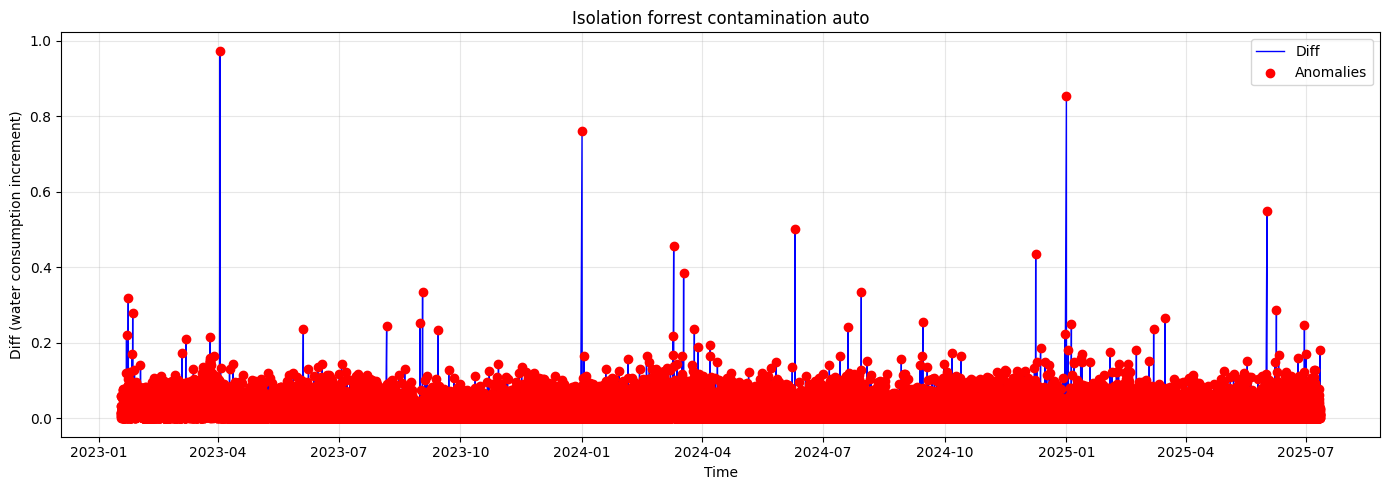

In [7]:
plot_meter_with_anomalies(df_with_anomalies_auto, title="Isolation forrest contamination auto")

In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats


def engineer_features_and_train_negbin(df, prob_threshold=0.001, n_lags=2):
    """
    Engineer features and train Negative Binomial regression for anomaly detection.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Must have columns 'timestamp_utc' and 'Diff'
    prob_threshold : float
        Probability threshold below which a point is flagged as anomaly (default 0.001 = 0.1%)
    n_lags : int
        Number of lagged Diff values to include as features (default 2)
        
    Returns:
    --------
    model : statsmodels GLM result
        Trained Negative Binomial model
    df_features : pandas.DataFrame
        DataFrame with engineered features, probabilities, and anomaly scores
    """
    
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Ensure timestamp is datetime
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])
    df = df.sort_values('timestamp_utc').reset_index(drop=True)
    
    # Drop NaN in Diff
    df = df.dropna(subset=['Diff'])
    
    # Negative Binomial requires non-negative integers
    # Round Diff and ensure non-negative (adjust if needed for your data)
    df['Diff_count'] = np.maximum(0, np.round(df['Diff'])).astype(int)
    
    # Convert timestamp to seconds since epoch
    df['timestamp_seconds'] = df['timestamp_utc'].astype(np.int64) / 1e9
    
    # Daily period features: 86400 seconds (24 hours)
    daily_period = 86400
    df['sin_daily'] = np.sin(2 * np.pi * df['timestamp_seconds'] / daily_period)
    df['cos_daily'] = np.cos(2 * np.pi * df['timestamp_seconds'] / daily_period)
    
    # Weekly period features: 604800 seconds (7 days)
    weekly_period = 604800
    df['sin_weekly'] = np.sin(2 * np.pi * df['timestamp_seconds'] / weekly_period)
    df['cos_weekly'] = np.cos(2 * np.pi * df['timestamp_seconds'] / weekly_period)
    
    # Add lagged features (recent history)
    for lag in range(1, n_lags + 1):
        df[f'Diff_lag{lag}'] = df['Diff'].shift(lag)
    
    # Add rolling mean (short-term average)
    df['rolling_mean_3'] = df['Diff'].rolling(window=3, min_periods=1).mean()
    
    # Drop rows with NaN in lag features (first few rows)
    df = df.dropna()
    
    if len(df) < 50:
        print("Warning: Not enough data after feature engineering (< 50 rows)")
        return None, df
    
    # Prepare feature matrix
    feature_columns = ['sin_daily', 'cos_daily', 'sin_weekly', 'cos_weekly']
    feature_columns += [f'Diff_lag{i}' for i in range(1, n_lags + 1)]
    feature_columns += ['rolling_mean_3']
    
    X = df[feature_columns].values
    X = sm.add_constant(X)  # Add intercept
    y = df['Diff_count'].values
    
    # Handle potential issues
    if np.isnan(X).any():
        print(f"Warning: Found {np.isnan(X).sum()} NaN values in features. Filling with 0.")
        X = np.nan_to_num(X, nan=0.0)
    
    # Train Negative Binomial regression
    print("\n=== Training Negative Binomial Model ===")
    print(f"Total samples: {len(df)}")
    print(f"Features: {feature_columns}")
    
    try:
        # Fit Negative Binomial GLM
        model = sm.GLM(y, X, family=sm.families.NegativeBinomial())
        result = model.fit()
        
        # Get predicted lambda (mean) for each observation
        lambda_pred = result.predict(X)
        
        # Get alpha (dispersion parameter) from the model
        # For statsmodels NegBin, alpha is stored in the family after fitting
        alpha = result.scale  # This is an approximation; for exact alpha use sm.NegativeBinomial
        
        # Calculate probability of observed value under predicted distribution
        # For Negative Binomial: p(y | mu, alpha)
        # We'll use scipy.stats for exact PMF calculation
        
        # Convert NegBin parameterization: statsmodels uses (mu, alpha)
        # scipy uses (n, p) where mu = n*(1-p)/p and var = n*(1-p)/p^2
        # Relationship: alpha = 1/n, so n = 1/alpha
        
        probabilities = []
        for i in range(len(y)):
            mu = lambda_pred[i]
            # NegBin variance = mu + alpha * mu^2
            # For scipy: n = mu^2 / (var - mu) = 1/alpha (approximately)
            n = 1.0 / alpha if alpha > 0 else 1.0
            p = n / (n + mu) if (n + mu) > 0 else 0.5
            
            # PMF: probability of observing exactly y[i]
            prob = stats.nbinom.pmf(y[i], n=n, p=p)
            probabilities.append(prob)
        
        df['predicted_lambda'] = lambda_pred
        df['probability'] = probabilities
        
        # Anomaly score: negative log probability (higher = more anomalous)
        df['anomaly_score'] = -np.log(np.maximum(df['probability'], 1e-10))
        
        # Flag anomalies based on probability threshold
        df['is_anomaly'] = df['probability'] < prob_threshold
        
        # Summary statistics
        n_anomalies = df['is_anomaly'].sum()
        print(f"\n=== Negative Binomial Training Complete ===")
        print(f"Model converged: {result.converged}")
        print(f"Dispersion parameter (alpha): {alpha:.4f}")
        print(f"Detected anomalies (prob < {prob_threshold}): {n_anomalies} ({100*n_anomalies/len(df):.2f}%)")
        print(f"\nProbability statistics:")
        print(f"  Mean: {df['probability'].mean():.6f}")
        print(f"  Median: {df['probability'].median():.6f}")
        print(f"  Min: {df['probability'].min():.6f}")
        print(f"  Max: {df['probability'].max():.6f}")
        
        # Create output dataframe
        output_columns = ['timestamp_utc', 'Diff', 'Diff_count', 'predicted_lambda', 
                         'probability', 'anomaly_score', 'is_anomaly']
        output_columns += feature_columns
        df_features = df[output_columns]
        
        return result, df_features
        
    except Exception as e:
        print(f"Error during model fitting: {e}")
        print("This might happen if:")
        print("  - Data has too many zeros (consider Zero-Inflated NegBin)")
        print("  - Variance is too small (try regular Poisson)")
        print("  - Not enough variation in features")
        return None, df


# Example usage:
if __name__ == "__main__":
    # Generate sample data
    np.random.seed(42)
    dates = pd.date_range('2024-01-01', periods=1000, freq='30min')
    
    # Simulate water consumption with daily pattern and random spikes
    hours = dates.hour + dates.minute / 60
    base_consumption = 10 + 8 * np.sin(2 * np.pi * (hours - 6) / 24)  # Daily pattern
    noise = np.random.gamma(shape=2, scale=2, size=len(dates))  # Overdispersed noise
    spikes = np.random.choice([0, 50], size=len(dates), p=[0.98, 0.02])  # Occasional spikes
    
    df = pd.DataFrame({
        'timestamp_utc': dates,
        'Diff': np.maximum(0, base_consumption + noise + spikes)
    })
    
    df = pd.read_csv('../data_w_diff_001/137402.csv')
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])
    
    # Train model
    model, df_with_anomalies = engineer_features_and_train_negbin(
        df, 
        prob_threshold=0.01,  # Flag points with < 1% probability
        n_lags=2
    )
    
    if model is not None:
        # Get anomalies
        anomalies = df_with_anomalies[df_with_anomalies['is_anomaly']]
        print(f"\n=== Sample of detected anomalies ===")
        print(anomalies[['timestamp_utc', 'Diff', 'predicted_lambda', 'probability', 'anomaly_score']].head(10))
        
        # Show model summary
        print("\n=== Model Summary ===")
        print(model.summary())



=== Training Negative Binomial Model ===
Total samples: 10132
Features: ['sin_daily', 'cos_daily', 'sin_weekly', 'cos_weekly', 'Diff_lag1', 'Diff_lag2', 'rolling_mean_3']


c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "



=== Negative Binomial Training Complete ===
Model converged: True
Dispersion parameter (alpha): 1.0000
Detected anomalies (prob < 0.01): 45 (0.44%)

Probability statistics:
  Mean: 0.524596
  Median: 0.675277
  Min: 0.000000
  Max: 0.899310

=== Sample of detected anomalies ===
                timestamp_utc   Diff  predicted_lambda  probability  \
11  2024-06-19 02:16:28+00:00  12.16        283.178288     0.003373   
122 2024-06-24 01:44:05+00:00  11.82        140.937837     0.006472   
214 2024-06-28 08:10:48+00:00  10.75        129.315706     0.007050   
294 2024-07-02 02:21:41+00:00  12.01        209.260055     0.004492   
312 2024-07-03 03:11:14+00:00  16.76       2397.860612     0.000414   
487 2024-07-12 02:08:56+00:00  10.73        120.500116     0.007515   
657 2024-07-20 02:10:23+00:00  10.99        118.706912     0.007617   
739 2024-07-24 02:12:09+00:00  10.55         89.129162     0.009814   
821 2024-07-28 01:09:55+00:00  11.17        105.178371     0.008487   
844 2024-0

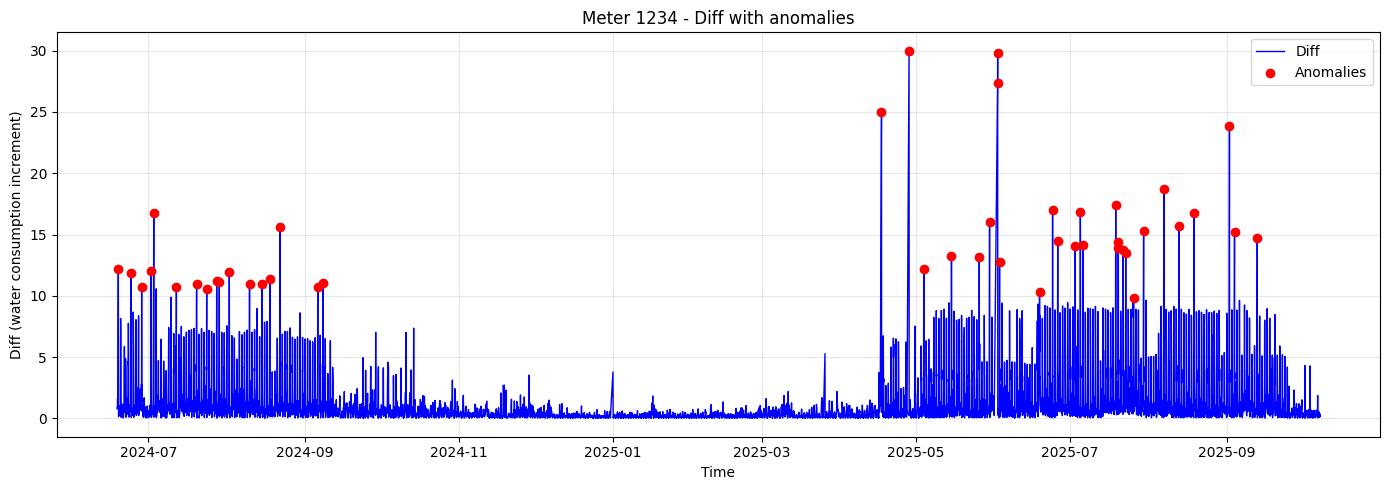

In [9]:
plot_meter_with_anomalies(df_with_anomalies, title="Meter 1234 - Diff with anomalies")

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats


def engineer_features_and_train_negbin_quantile(df, anomaly_quantile=0.99, n_lags=2):
    """
    Engineer features and train Negative Binomial regression for anomaly detection.
    Uses quantile-based threshold on anomaly scores instead of absolute probability.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Must have columns 'timestamp_utc' and 'Diff'
    anomaly_quantile : float
        Quantile threshold for anomaly scores (default 0.99 = top 1% are anomalies)
    n_lags : int
        Number of lagged Diff values to include as features (default 2)
        
    Returns:
    --------
    model : statsmodels GLM result
        Trained Negative Binomial model
    df_features : pandas.DataFrame
        DataFrame with engineered features, probabilities, and anomaly scores
    thresholds : dict
        Dictionary containing score_threshold and prob_threshold for production use
    """
    
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Ensure timestamp is datetime
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])
    df = df.sort_values('timestamp_utc').reset_index(drop=True)
    
    # Drop NaN in Diff
    df = df.dropna(subset=['Diff'])
    
    # Negative Binomial requires non-negative integers
    # Round Diff and ensure non-negative
    df['Diff_count'] = np.maximum(0, np.round(df['Diff'])).astype(int)
    
    # Convert timestamp to seconds since epoch
    df['timestamp_seconds'] = df['timestamp_utc'].astype(np.int64) / 1e9
    
    # Daily period features: 86400 seconds (24 hours)
    daily_period = 86400
    df['sin_daily'] = np.sin(2 * np.pi * df['timestamp_seconds'] / daily_period)
    df['cos_daily'] = np.cos(2 * np.pi * df['timestamp_seconds'] / daily_period)
    
    # Weekly period features: 604800 seconds (7 days)
    weekly_period = 604800
    df['sin_weekly'] = np.sin(2 * np.pi * df['timestamp_seconds'] / weekly_period)
    df['cos_weekly'] = np.cos(2 * np.pi * df['timestamp_seconds'] / weekly_period)
    
    # Add lagged features (recent history)
    for lag in range(1, n_lags + 1):
        df[f'Diff_lag{lag}'] = df['Diff'].shift(lag)
    
    # Add rolling mean (short-term average)
    df['rolling_mean_3'] = df['Diff'].rolling(window=3, min_periods=1).mean()
    
    # Drop rows with NaN in lag features (first few rows)
    df = df.dropna()
    
    if len(df) < 50:
        print("Warning: Not enough data after feature engineering (< 50 rows)")
        return None, df, None
    
    # Prepare feature matrix
    feature_columns = ['sin_daily', 'cos_daily', 'sin_weekly', 'cos_weekly']
    feature_columns += [f'Diff_lag{i}' for i in range(1, n_lags + 1)]
    feature_columns += ['rolling_mean_3']
    
    X = df[feature_columns].values
    X = sm.add_constant(X)  # Add intercept
    y = df['Diff_count'].values
    
    # Handle potential issues
    if np.isnan(X).any():
        print(f"Warning: Found {np.isnan(X).sum()} NaN values in features. Filling with 0.")
        X = np.nan_to_num(X, nan=0.0)
    
    # Train Negative Binomial regression
    print("\n=== Training Negative Binomial Model ===")
    print(f"Total samples: {len(df)}")
    print(f"Features: {feature_columns}")
    
    try:
        # Fit Negative Binomial GLM
        model = sm.GLM(y, X, family=sm.families.NegativeBinomial())
        result = model.fit()
        
        # Get predicted lambda (mean) for each observation
        lambda_pred = result.predict(X)
        
        # Get alpha (dispersion parameter)
        alpha = result.scale
        
        # Calculate probability of observed value under predicted distribution
        probabilities = []
        for i in range(len(y)):
            mu = lambda_pred[i]
            # NegBin parameterization for scipy
            n = 1.0 / alpha if alpha > 0 else 1.0
            p = n / (n + mu) if (n + mu) > 0 else 0.5
            
            # PMF: probability of observing exactly y[i]
            prob = stats.nbinom.pmf(y[i], n=n, p=p)
            probabilities.append(prob)
        
        df['predicted_lambda'] = lambda_pred
        df['probability'] = probabilities
        
        # Anomaly score: negative log probability (higher = more anomalous)
        df['anomaly_score'] = -np.log(np.maximum(df['probability'], 1e-10))
        
        # ===== QUANTILE-BASED THRESHOLD =====
        # Find the score at the specified quantile
        score_threshold = df['anomaly_score'].quantile(anomaly_quantile)
        
        # Corresponding probability threshold (for production use)
        prob_threshold = np.exp(-score_threshold)
        
        # Flag anomalies: top (1 - anomaly_quantile) percent
        df['is_anomaly'] = df['anomaly_score'] >= score_threshold
        
        # Store thresholds for production use
        thresholds = {
            'score_threshold': score_threshold,
            'prob_threshold': prob_threshold,
            'anomaly_quantile': anomaly_quantile
        }
        
        # Summary statistics
        n_anomalies = df['is_anomaly'].sum()
        actual_pct = 100 * n_anomalies / len(df)
        
        print(f"\n=== Negative Binomial Training Complete ===")
        print(f"Model converged: {result.converged}")
        print(f"Dispersion parameter (alpha): {alpha:.4f}")
        print(f"\n=== Quantile-based threshold ===")
        print(f"Anomaly quantile: {anomaly_quantile} (targeting top {100*(1-anomaly_quantile):.1f}%)")
        print(f"Score threshold: {score_threshold:.4f}")
        print(f"Probability threshold: {prob_threshold:.6f}")
        print(f"Detected anomalies: {n_anomalies} ({actual_pct:.2f}%)")
        
        print(f"\n=== Probability statistics ===")
        print(f"  Mean: {df['probability'].mean():.6f}")
        print(f"  Median: {df['probability'].median():.6f}")
        print(f"  Min: {df['probability'].min():.6f}")
        print(f"  Max: {df['probability'].max():.6f}")
        
        print(f"\n=== Anomaly score statistics ===")
        print(f"  Mean: {df['anomaly_score'].mean():.4f}")
        print(f"  Median: {df['anomaly_score'].median():.4f}")
        print(f"  Min: {df['anomaly_score'].min():.4f}")
        print(f"  Max: {df['anomaly_score'].max():.4f}")
        
        # Create output dataframe
        output_columns = ['timestamp_utc', 'Diff', 'Diff_count', 'predicted_lambda', 
                         'probability', 'anomaly_score', 'is_anomaly']
        output_columns += feature_columns
        df_features = df[output_columns]
        
        return result, df_features, thresholds
        
    except Exception as e:
        print(f"Error during model fitting: {e}")
        print("This might happen if:")
        print("  - Data has too many zeros (consider Zero-Inflated NegBin)")
        print("  - Variance is too small (try regular Poisson)")
        print("  - Not enough variation in features")
        return None, df, None


def predict_anomalies_production(new_df, model, thresholds, n_lags=2):
    """
    Use trained model and thresholds to detect anomalies in new data (production mode).
    
    Parameters:
    -----------
    new_df : pandas.DataFrame
        New data with columns 'timestamp_utc' and 'Diff'
    model : statsmodels GLM result
        Trained model from engineer_features_and_train_negbin_quantile
    thresholds : dict
        Thresholds from training (contains 'score_threshold' and 'prob_threshold')
    n_lags : int
        Number of lags used during training (must match)
        
    Returns:
    --------
    df_predictions : pandas.DataFrame
        DataFrame with predictions and anomaly flags
    """
    
    # Make a copy
    df = new_df.copy()
    
    # Ensure timestamp is datetime
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])
    df = df.sort_values('timestamp_utc').reset_index(drop=True)
    
    # Drop NaN in Diff
    df = df.dropna(subset=['Diff'])
    
    # Round to count
    df['Diff_count'] = np.maximum(0, np.round(df['Diff'])).astype(int)
    
    # Convert timestamp to seconds
    df['timestamp_seconds'] = df['timestamp_utc'].astype(np.int64) / 1e9
    
    # Daily features
    daily_period = 86400
    df['sin_daily'] = np.sin(2 * np.pi * df['timestamp_seconds'] / daily_period)
    df['cos_daily'] = np.cos(2 * np.pi * df['timestamp_seconds'] / daily_period)
    
    # Weekly features
    weekly_period = 604800
    df['sin_weekly'] = np.sin(2 * np.pi * df['timestamp_seconds'] / weekly_period)
    df['cos_weekly'] = np.cos(2 * np.pi * df['timestamp_seconds'] / weekly_period)
    
    # Lagged features
    for lag in range(1, n_lags + 1):
        df[f'Diff_lag{lag}'] = df['Diff'].shift(lag)
    
    # Rolling mean
    df['rolling_mean_3'] = df['Diff'].rolling(window=3, min_periods=1).mean()
    
    # Drop rows with NaN
    df = df.dropna()
    
    if len(df) == 0:
        print("Warning: No valid data after feature engineering")
        return df
    
    # Prepare features
    feature_columns = ['sin_daily', 'cos_daily', 'sin_weekly', 'cos_weekly']
    feature_columns += [f'Diff_lag{i}' for i in range(1, n_lags + 1)]
    feature_columns += ['rolling_mean_3']
    
    X = df[feature_columns].values
    X = sm.add_constant(X)
    X = np.nan_to_num(X, nan=0.0)
    
    y = df['Diff_count'].values
    
    # Predict
    lambda_pred = model.predict(X)
    alpha = model.scale
    
    # Calculate probabilities
    probabilities = []
    for i in range(len(y)):
        mu = lambda_pred[i]
        n = 1.0 / alpha if alpha > 0 else 1.0
        p = n / (n + mu) if (n + mu) > 0 else 0.5
        prob = stats.nbinom.pmf(y[i], n=n, p=p)
        probabilities.append(prob)
    
    df['predicted_lambda'] = lambda_pred
    df['probability'] = probabilities
    df['anomaly_score'] = -np.log(np.maximum(df['probability'], 1e-10))
    
    # Use the stored threshold from training
    score_threshold = thresholds['score_threshold']
    df['is_anomaly'] = df['anomaly_score'] >= score_threshold
    
    print(f"\n=== Production Predictions ===")
    print(f"Total samples: {len(df)}")
    print(f"Using score threshold: {score_threshold:.4f}")
    print(f"Detected anomalies: {df['is_anomaly'].sum()} ({100*df['is_anomaly'].mean():.2f}%)")
    
    return df[['timestamp_utc', 'Diff', 'predicted_lambda', 'probability', 
               'anomaly_score', 'is_anomaly']]


# Example usage:
if __name__ == "__main__":
    # Generate sample data
    np.random.seed(42)
    dates = pd.date_range('2024-01-01', periods=2000, freq='30min')
    
    # Simulate water consumption with daily pattern and random spikes
    hours = dates.hour + dates.minute / 60
    base_consumption = 10 + 8 * np.sin(2 * np.pi * (hours - 6) / 24)
    noise = np.random.gamma(shape=2, scale=2, size=len(dates))
    spikes = np.random.choice([0, 50], size=len(dates), p=[0.99, 0.01])  # 1% spikes
    
    df = pd.DataFrame({
        'timestamp_utc': dates,
        'Diff': np.maximum(0, base_consumption + noise + spikes)
    })
    
    # Train model with quantile-based threshold
    model, df_with_anomalies, thresholds = engineer_features_and_train_negbin_quantile(
        df, 
        anomaly_quantile=0.99,  # Top 1% are anomalies
        n_lags=2
    )
    
    if model is not None:
        # Show detected anomalies
        anomalies = df_with_anomalies[df_with_anomalies['is_anomaly']]
        print(f"\n=== Sample of detected anomalies ===")
        print(anomalies[['timestamp_utc', 'Diff', 'predicted_lambda', 'probability', 'anomaly_score']].head(10))
        
        # Simulate production: new data arrives
        print("\n" + "="*60)
        print("=== PRODUCTION MODE: New data arrives ===")
        print("="*60)
        
        new_dates = pd.date_range('2024-02-01', periods=100, freq='30min')
        new_hours = new_dates.hour + new_dates.minute / 60
        new_base = 10 + 8 * np.sin(2 * np.pi * (new_hours - 6) / 24)
        new_noise = np.random.gamma(shape=2, scale=2, size=len(new_dates))
        new_spikes = np.random.choice([0, 60], size=len(new_dates), p=[0.98, 0.02])
        
        new_df = pd.DataFrame({
            'timestamp_utc': new_dates,
            'Diff': np.maximum(0, new_base + new_noise + new_spikes)
        })
        
        # Predict using stored thresholds
        predictions = predict_anomalies_production(new_df, model, thresholds, n_lags=2)
        
        print("\n=== New anomalies detected ===")
        print(predictions[predictions['is_anomaly']][['timestamp_utc', 'Diff', 'probability', 'anomaly_score']])



=== Training Negative Binomial Model ===
Total samples: 1998
Features: ['sin_daily', 'cos_daily', 'sin_weekly', 'cos_weekly', 'Diff_lag1', 'Diff_lag2', 'rolling_mean_3']


c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "



=== Negative Binomial Training Complete ===
Model converged: True
Dispersion parameter (alpha): 1.0000

=== Quantile-based threshold ===
Anomaly quantile: 0.99 (targeting top 1.0%)
Score threshold: 4.4952
Probability threshold: 0.011162
Detected anomalies: 20 (1.00%)

=== Probability statistics ===
  Mean: 0.031550
  Median: 0.024931
  Min: 0.002653
  Max: 0.110486

=== Anomaly score statistics ===
  Mean: 3.5946
  Median: 3.6916
  Min: 2.2029
  Max: 5.9319

=== Sample of detected anomalies ===
           timestamp_utc       Diff  predicted_lambda  probability  \
135  2024-01-03 19:30:00  59.195792        108.700265     0.005311   
161  2024-01-04 08:30:00  65.700656        193.740012     0.003656   
183  2024-01-04 19:30:00  62.844428        132.439527     0.004666   
503  2024-01-11 11:30:00  32.972141         40.898793     0.010755   
741  2024-01-16 10:30:00  68.354966        234.692410     0.003178   
769  2024-01-17 00:30:00  59.544132         97.070581     0.005513   
783  2024

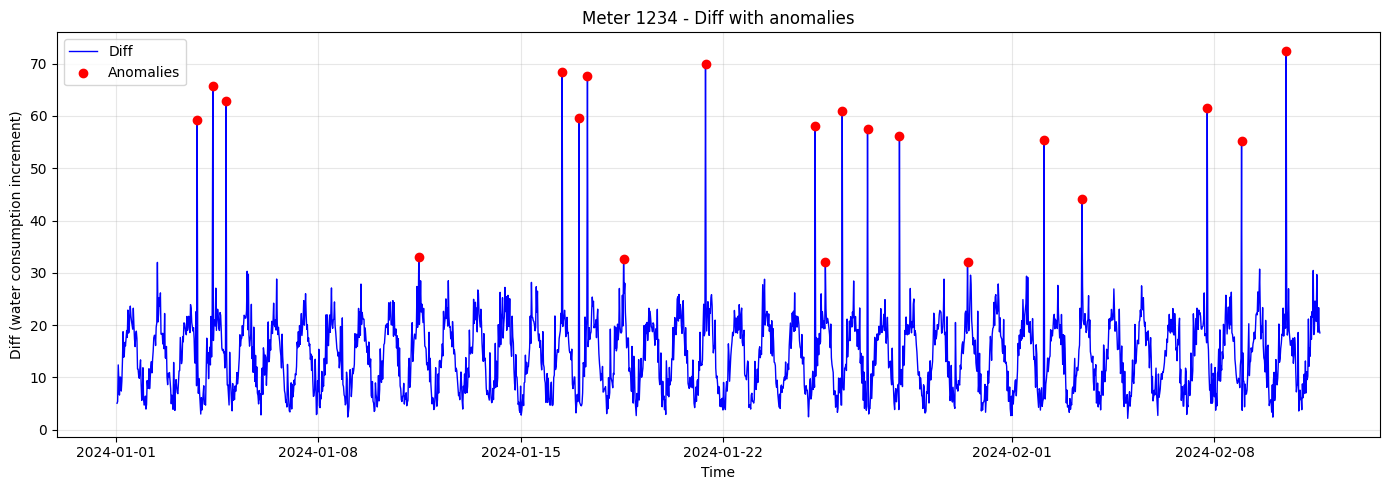

In [11]:
plot_meter_with_anomalies(df_with_anomalies, title="Meter 1234 - Diff with anomalies")

In [12]:
meter_id = 137403

In [13]:
df = pd.read_csv(f'../data_w_diff_001/{meter_id}.csv')
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])

model, df_with_anomalies, thresholds = engineer_features_and_train_negbin_quantile(
        df, 
        anomaly_quantile=0.99,  # Top 1% are anomalies
        n_lags=2
)


=== Training Negative Binomial Model ===
Total samples: 11144
Features: ['sin_daily', 'cos_daily', 'sin_weekly', 'cos_weekly', 'Diff_lag1', 'Diff_lag2', 'rolling_mean_3']


c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\Ond


=== Negative Binomial Training Complete ===
Model converged: True
Dispersion parameter (alpha): 1.0000

=== Quantile-based threshold ===
Anomaly quantile: 0.99 (targeting top 1.0%)
Score threshold: 0.0000
Probability threshold: 1.000000
Detected anomalies: 112 (1.01%)

=== Probability statistics ===
  Mean: 0.999915
  Median: 1.000000
  Min: 0.056653
  Max: 1.000000

=== Anomaly score statistics ===
  Mean: 0.0003
  Median: 0.0000
  Min: -0.0000
  Max: 2.8708


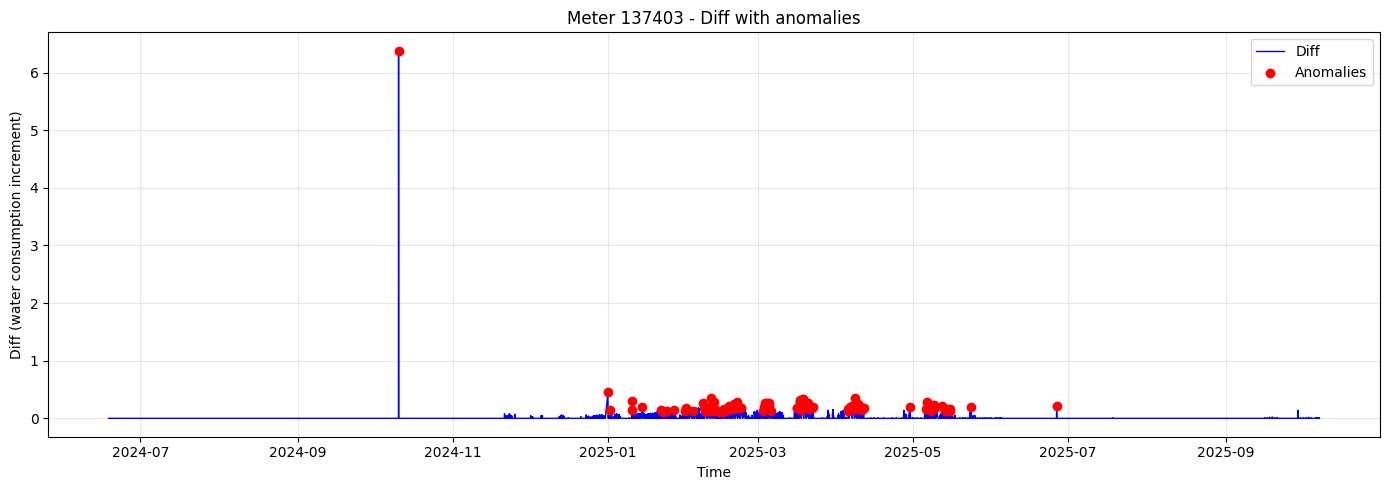

In [14]:
plot_meter_with_anomalies(df_with_anomalies, title=f"Meter {meter_id} - Diff with anomalies")